#  Computation of BOP Features

- input: atoms objects
- output here: all the descriptors comming from BOP (averages, atomic site based, etc)

#  Calculation of features from available libraries

- input curated BS

# TODO
- [X] Calculate site specific averages
- [ ] Distributions of descriptors / characterization of descriptors

In [1]:
import os
import sys
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer import Featurizer, BopfoxFeatures
import pandas as pd

## options:

In [2]:
dataset = 'Cr-Co-W'# 'Fe-Mo'
atomsobjectloc = os.path.join(dataset, 'Atomsobjects')
components = dataset.replace('-','')
models = ['canonical','projections', 'projections_os']
cutoff = 'table'
atoms = 'initial'
moments = 16

In [3]:
# only loop over the models
atomspickle =  os.path.join(atomsobjectloc, f'{components}-POSCAR-{atoms}-rescaled-AtomsObjects.pkl')
AtomsObjects = pd.read_pickle(atomspickle).dropna(how='any')

In [4]:
model = 'canonical'

In [5]:
results = {}
resultspickle = {}
for model in models:
    modelsfile = os.path.join('models', f'{components}_{model}.bx')
    print('atoms: ', atoms, 'model: ', model, '  cutoff: ', cutoff, ' moments:', moments)
    resultspickle[model] = os.path.join(dataset, 'Descriptors', f'parallel_{components}_{atoms}_{model}_{cutoff}_WUBIND_{moments}.pkl')
#    BOPC = BopfoxFeatures(
#            AtomsObjects['atoms'],modelsfile, modelname=model,
#            cutoffby=cutoff, 
#            binary = '/home/storage/fortimtb/CuadernoTrabajo/oldrepobopfox/src/bopfox_mpi',
#            moments = moments
#            )
#    BOPC.calculate_bop_forall(ForceKeepSpecies=True,
#            input_pickle = resultspickle[model]
#            )
#    results[model] = BOPC.RESULTS #pd.read_pickle(resultspickle[model]) #
    results[model] = pd.read_pickle(resultspickle[model]) #

atoms:  initial model:  canonical   cutoff:  table  moments: 16
atoms:  initial model:  projections   cutoff:  table  moments: 16
atoms:  initial model:  projections_os   cutoff:  table  moments: 16


# Failed BOP Calculations 

In [6]:
for model, result in results.items():
    print(f'{model} model:')
    print(result.isna().sum())
    print(result[result.isna().any(axis=1)])
    print('=================')

canonical model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections_os model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dt

##  remove bad data

In [7]:
removenans = [result.dropna(inplace=True) for model, result in results.items()]

In [8]:
for model, result in results.items():
    print(f'{model} model:')
    print(result.isna().sum())
    print(result[result.isna().any(axis=1)])
    print('=================')

canonical model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections_os model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dt

In [9]:
for (model, resultpckl), result in zip(resultspickle.items(), results.values()):
    result.to_pickle(resultpckl)

# Arrangement and averaging BOP Features 

- expand arrays of atomwise quantities to quantities averages
- calculate shape factors, $b_1 / b_2$ averages (over CP and structure)
- remove features with constant values (null variance)

In [17]:
from Tools.DatasetTools import GeneralFeaturizer as gf
from sklearn.feature_selection import VarianceThreshold
from tqdm.auto import tqdm

In [18]:
descriptorlocation = os.path.join(dataset, 'Descriptors' )

In [19]:
CNListLocation = os.path.join(descriptorlocation,'CNList.pkl')

In [20]:
CNList = pd.read_pickle(CNListLocation)

In [21]:
resultscnav = {}
specialcolumns =['U_bind','U_bond_atom', 'U_bond_atom_list'] 
for model, result in tqdm(results.items()):
    columnstoexpand = result.columns.drop(specialcolumns)
    df = gf.array_expansions(result, columnstoexpand)
    ThisCoordination = CNList[result.index]
    df = gf.featurize_dataframe(df, ThisCoordination)
    shape_factors = gf.get_shape_factors(df)
    df = pd.concat([result[specialcolumns[:-1]], df, shape_factors],  axis=1)
    selector = VarianceThreshold()
    selector.fit(df)
    resultscnav[model] = df.loc[:, selector.get_support()]
    averaged_bop_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(resultspickle[model]))
    resultscnav[model].to_pickle(averaged_bop_file)

  0%|          | 0/3 [00:00<?, ?it/s]

In [22]:
resultscnav['projections_os']

,U_bind,U_bond_atom,moments_1_0,moments_1_CN12,moments_1_CN13,moments_1_CN14,moments_1_CN15,moments_1_CN16,moments_2_0,moments_2_CN12,...,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16
Co_pv6W_sv6.C14-BBA.FM,-120.002266,-110.387407,48.106100,38.787267,0.000000,0.000000,0.000000,9.318833,-418.475500,-344.764833,...,0.000000,0.000000,0.000000,1.210548,0.931245,0.875535,0.000000,0.000000,0.000000,1.039340
Co_pv6W_sv6.C14-BBA.NM,-120.002266,-110.387407,48.106100,38.787267,0.000000,0.000000,0.000000,9.318833,-418.475500,-344.764833,...,0.000000,0.000000,0.000000,1.210548,0.931245,0.875535,0.000000,0.000000,0.000000,1.039340
Cr_pv6W_sv2.D0_19-A3B.FM,-78.184461,-83.497746,15.702325,15.702325,0.000000,0.000000,0.000000,0.000000,-97.387850,-97.387850,...,0.000000,0.000000,0.000000,0.000000,1.047835,1.047835,0.000000,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,-78.184461,-83.497746,15.702325,15.702325,0.000000,0.000000,0.000000,0.000000,-97.387850,-97.387850,...,0.000000,0.000000,0.000000,0.000000,1.047835,1.047835,0.000000,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,-327.881431,-319.802263,25.801240,12.419027,0.000000,11.887720,1.494493,0.000000,-199.532307,-100.562993,...,0.000000,2.242107,0.598321,0.000000,0.949554,0.835211,0.000000,1.041792,0.841225,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,-311.423319,-316.000015,20.164293,7.600207,0.000000,11.023553,1.540533,0.000000,-143.288413,-57.440020,...,0.000000,1.888829,0.466215,0.000000,1.031192,0.881681,0.000000,1.159421,0.918321,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,-311.423319,-316.000015,20.164293,7.600207,0.000000,11.023553,1.540533,0.000000,-143.288413,-57.440020,...,0.000000,1.888829,0.466215,0.000000,1.031192,0.881681,0.000000,1.159421,0.918321,0.000000
Co_pv13W_sv16.chi-ABAB.NM,-344.693837,-324.720823,48.496128,14.412372,27.472552,0.000000,0.000000,6.611203,-429.008310,-131.748414,...,1.800631,0.000000,0.000000,0.720221,0.921635,1.274397,0.562604,0.000000,0.000000,1.033557
Co_pv13W_sv16.chi-ABAB.FM,-344.693837,-324.720823,48.496128,14.412372,27.472552,0.000000,0.000000,6.611203,-429.008310,-131.748414,...,1.800631,0.000000,0.000000,0.720221,0.921635,1.274397,0.562604,0.000000,0.000000,1.033557


# Characterization of BOP features 

In [23]:
resultscnav['projections_os'].filter(regex='an_.*_0$|bn_.*_0$').shape

(1700, 15)

In [24]:
import re

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,8))
plt.rc('font', size=22)

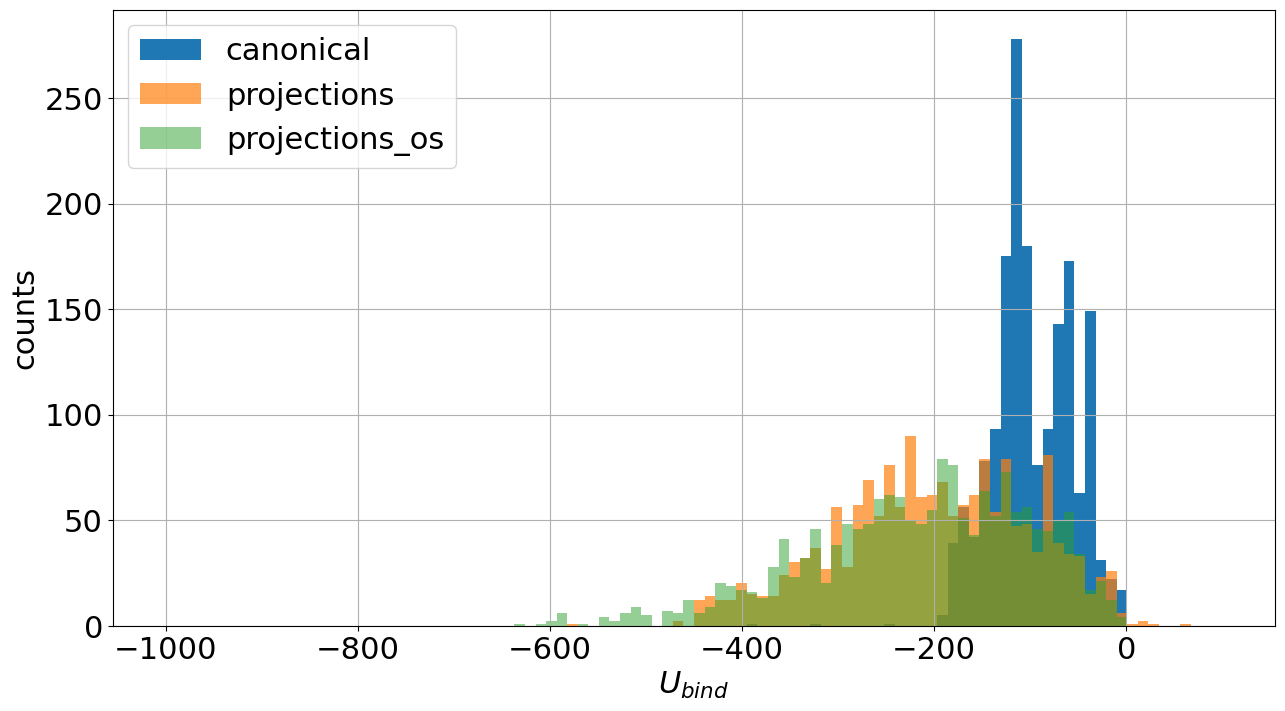

In [37]:
ax = resultscnav['canonical']['U_bind'].hist(bins=100, range=[-1000,100], label='canonical')
resultscnav['projections']['U_bind'].hist(bins=100, ax=ax, alpha=0.7, range=[-1000,100], label='projections')
resultscnav['projections_os']['U_bind'].hist(bins=100, ax=ax, alpha=0.5,range=[-1000,100], label='projections_os')
ax.set_xlabel('$U_{bind}$')
ax.set_ylabel('counts')
ax.legend()

In [27]:
def comparefeatures(featurename, featuresymbol):
    plotfeature = {f'{featurename}_{i}_0': fr'$\langle {featuresymbol}_{i} \rangle $' for i in range(1,4)}
    nplots = len(plotfeature)
    fig = plt.figure(figsize=(7*nplots, 5))
    ax = fig.subplots(1, nplots, sharey=True)
    ensamble = []
    for thisresultcnav, thisname in zip(resultscnav.values(), plotfeature.keys()):
        ensamble.append(thisresultcnav[thisname] )
    ensamble = pd.concat(ensamble, axis=0)
    thisrange = [ensamble.min(), ensamble.max()]
    for i, (feature, title) in enumerate(plotfeature.items()):
        ax[i].set_xlabel(title)
        for model, result in resultscnav.items():
            ax[i].hist(result[feature], density=True, bins=100, alpha=0.81, edgecolor='k', label=model, range=thisrange)
    ax[-1].legend()
    ax[0].set_ylabel('Counts')
    fig.tight_layout()

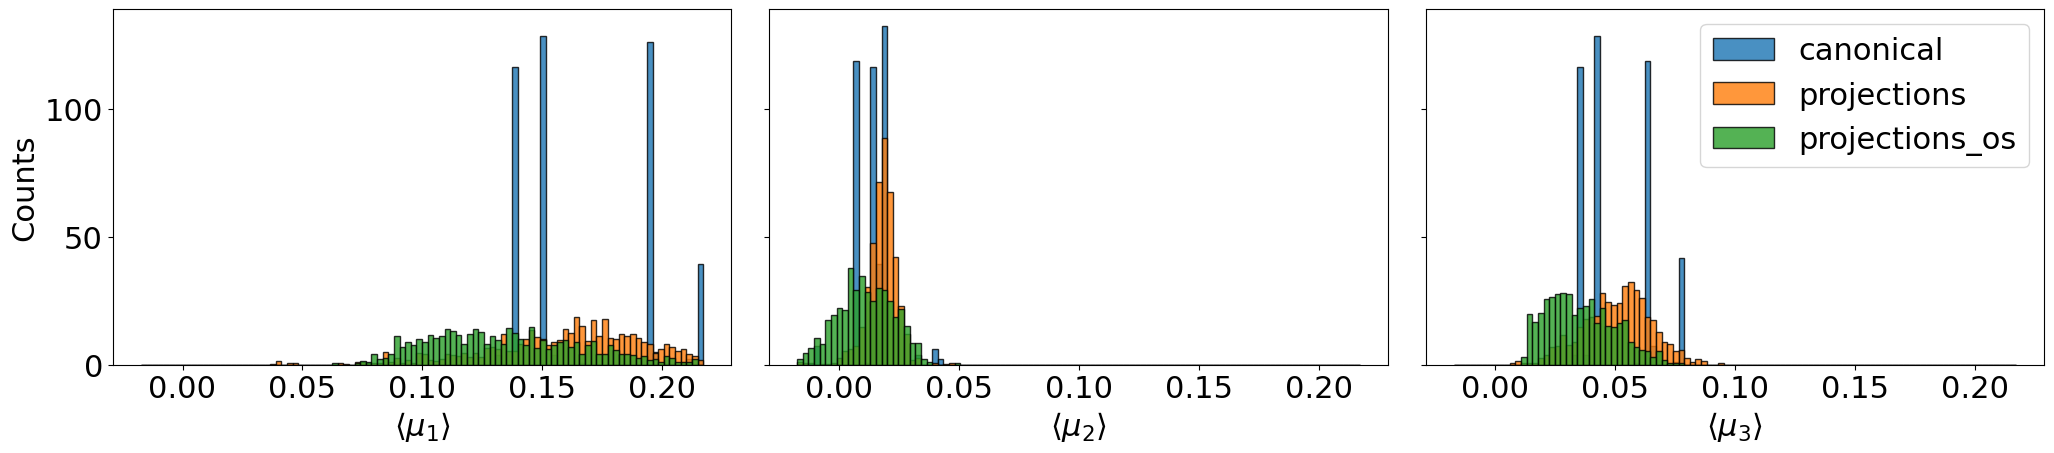

In [28]:
comparefeatures('normed_moments','\mu')

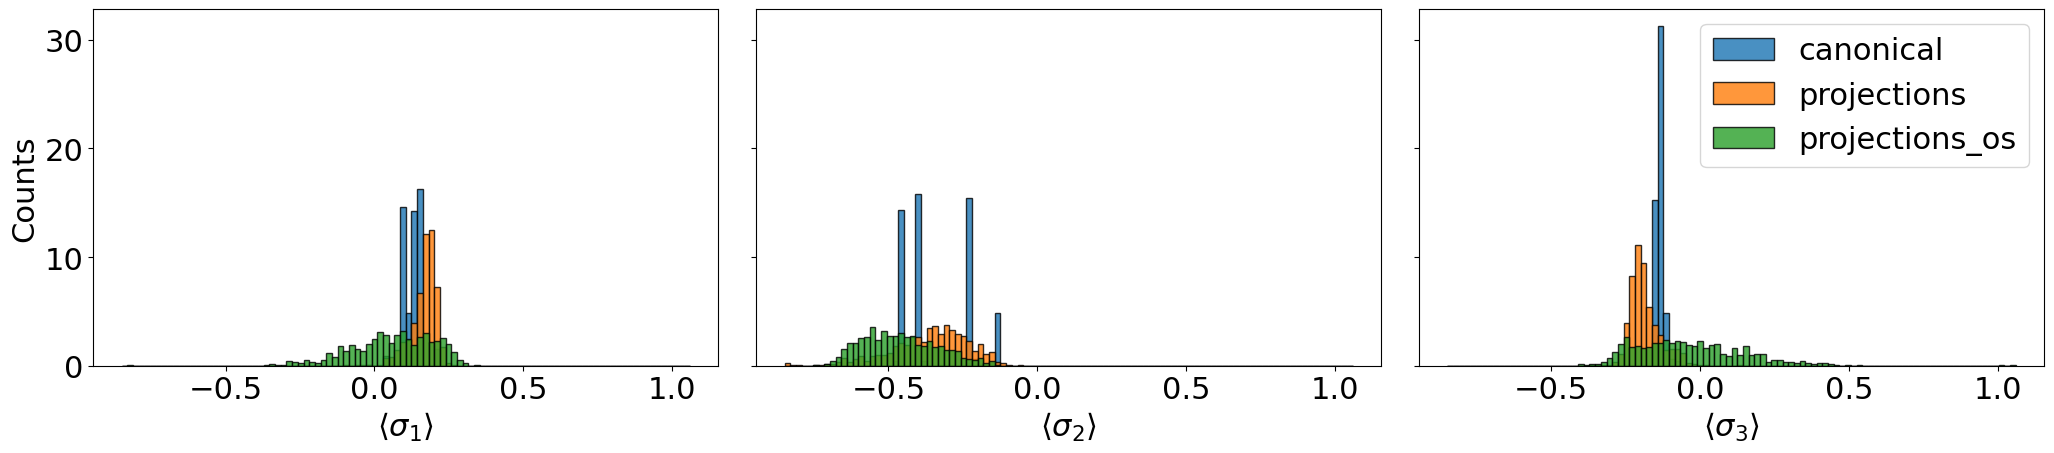

In [29]:
comparefeatures('sigma', '\sigma')

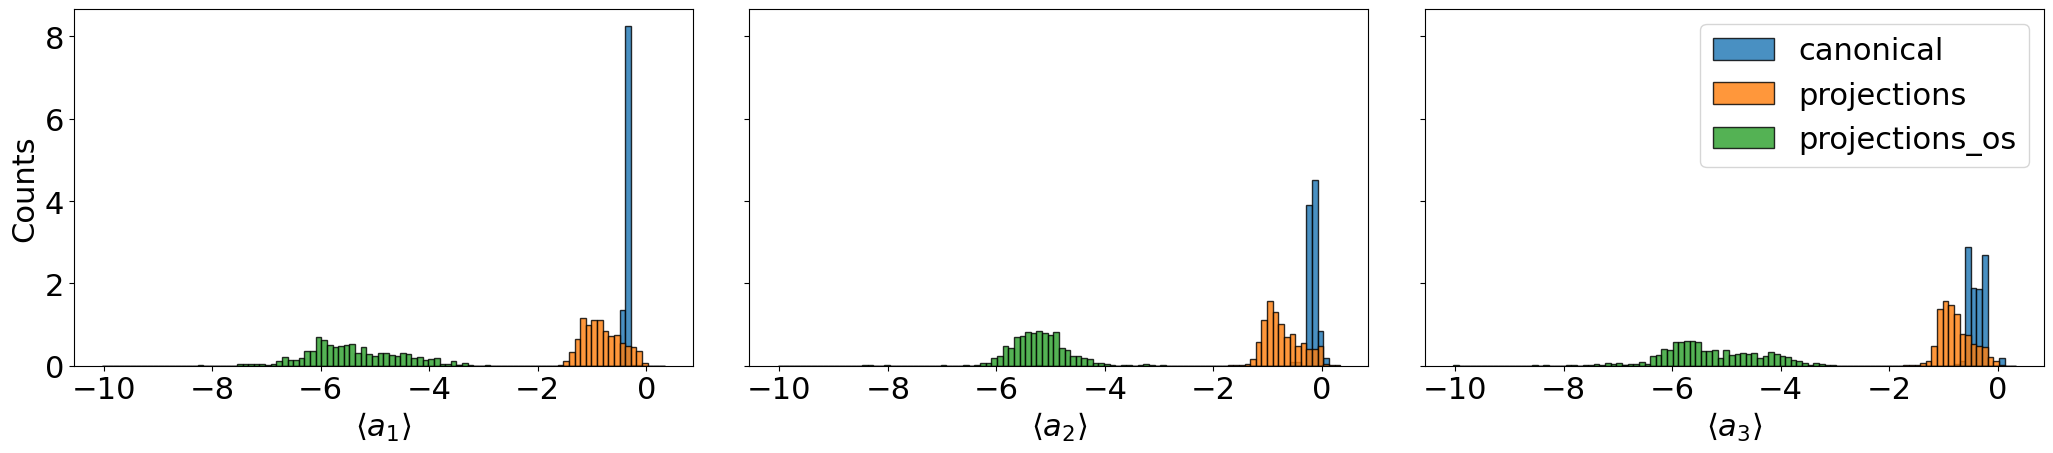

In [30]:
comparefeatures('an', 'a')

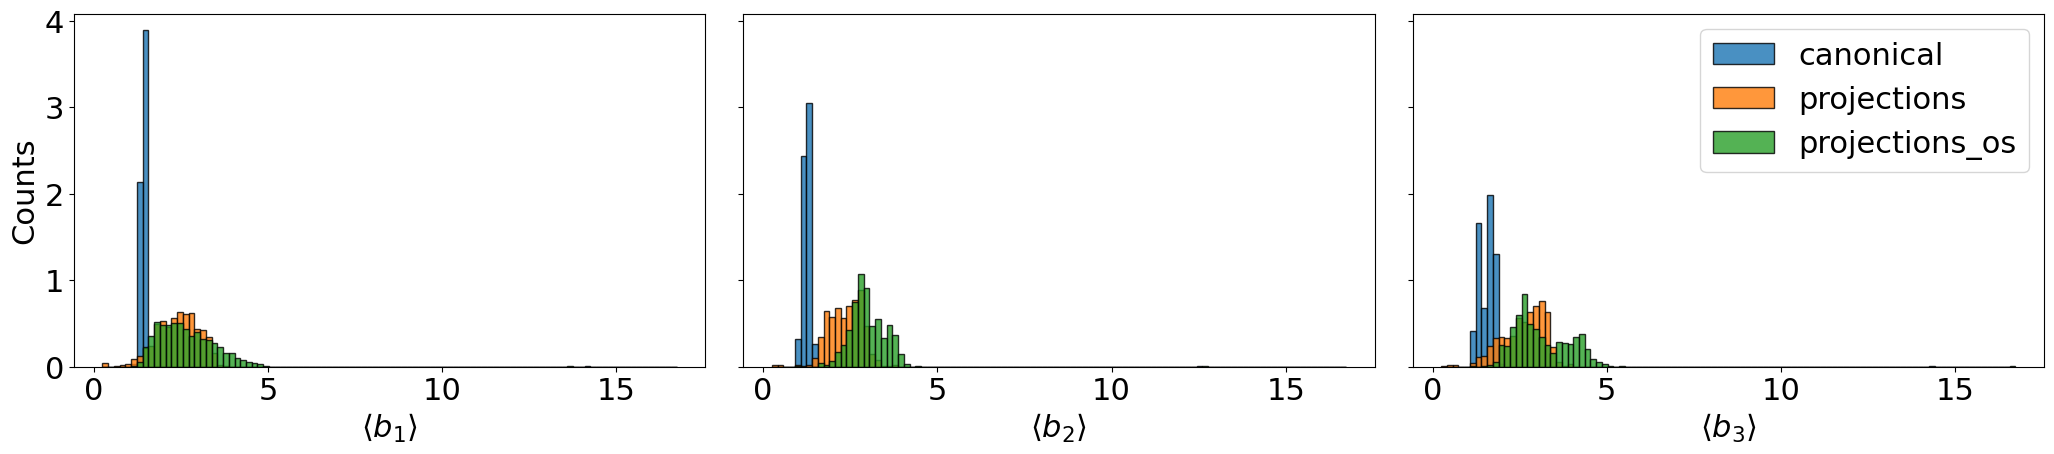

In [31]:
comparefeatures('bn', 'b')

In [38]:
CP = ['0', 'CN12', 'CN13', 'CN14','CN15','CN16']
CPSYMB=['_{0}',  '{CN_{12}}', '{CN_{13}}', '{CN_{14}}','{CN_{15}}','{CN_{16}}']

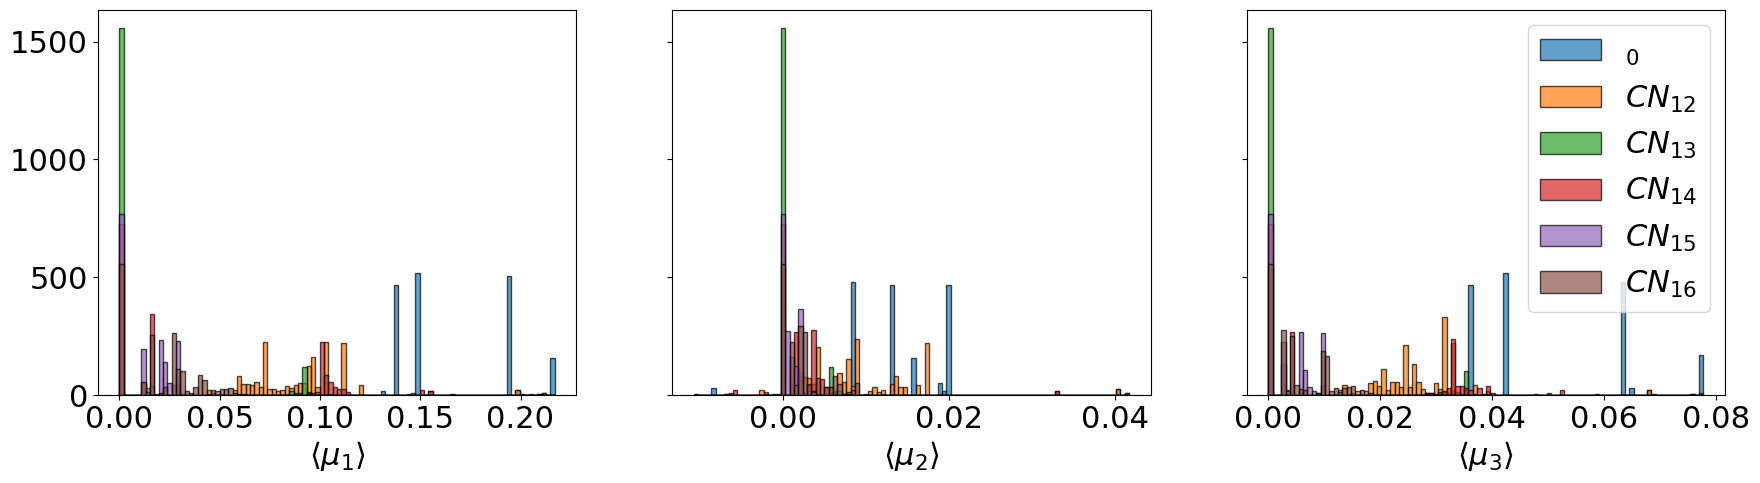

In [25]:
featurename = 'normed_moments'
featuresymbol = '\mu'
fig, ax = plt.subplots(1,3, figsize = (21,5), sharey=True)
for i, tax in enumerate(ax):
    for case, symbol in zip(CP,CPSYMB):
        featuremain = fr'{featurename}_{i+1}' 
        featurecol = fr'{featuremain}_{case}'
        featuretitle = fr'$\langle {featuresymbol}_{i+1} \rangle$'
        tax.set_xlabel(featuretitle)
        thismin = resultscnav['canonical'].filter(regex=featuremain+'_').min().min()
        thismaxn = resultscnav['canonical'].filter(regex=featuremain+'_').max().max()
    #     = fr'${featuresymbol}_{i} $' for i in range(1,4)}
        tax.hist(resultscnav['canonical'][f'{featurecol}'], label=f'${symbol}$',bins=100, edgecolor='k', alpha=0.7, range=[thismin, thismaxn])
ax[-1].legend()

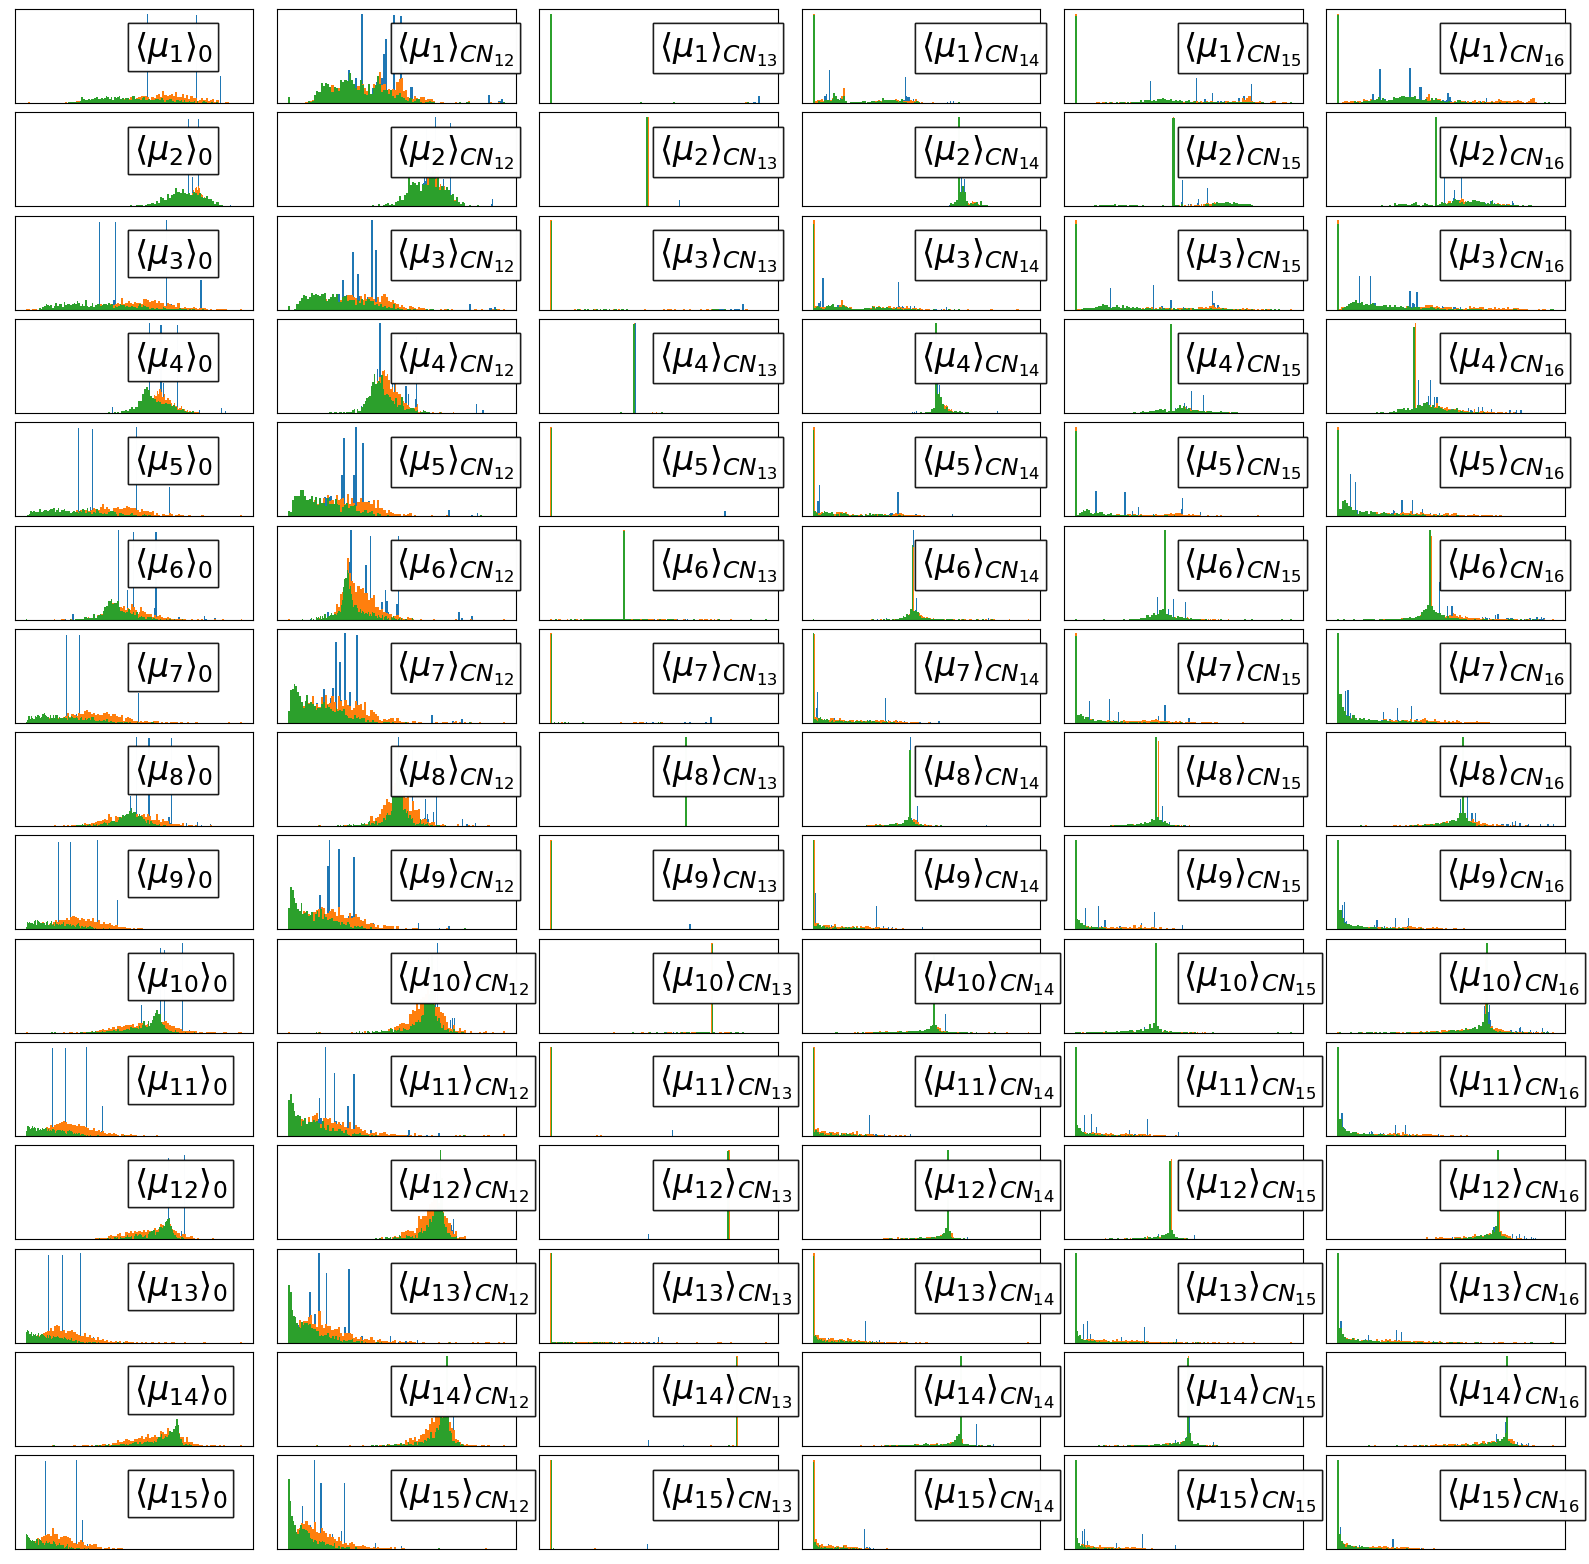

In [26]:
import Tools.DatasetTools.Tools as tl
plotter = tl.Plotting
selection = resultscnav['canonical'].columns.str.contains('normed_moments')
normedmomentnames = resultscnav['canonical'].columns[selection]
normedmomenttitles = pd.Series({name: re.sub('normed_moments_(.*)_',r'$\\langle \\mu_{\1} \\rangle ', name)+'$' for name in normedmomentnames})
normedmomenttitles = normedmomenttitles.map(lambda s: re.sub(' 0\$','_{0}$', s))
normedmomenttitles = normedmomenttitles.map(lambda s: re.sub(' CN(.*)\$','_{CN_{\\1}}$', s))
fig, ax = plotter.histoff_realfeatures(resultscnav['canonical'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6)
fig, ax = plotter.histoff_realfeatures(resultscnav['projections'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6, fig_ax=(fig, ax))
fig, ax = plotter.histoff_realfeatures(resultscnav['projections_os'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6, fig_ax=(fig, ax))

## Shape factors 

In [40]:
BS = pd.read_pickle('Cr-Co-W/FullyCuratedParsedBriefSummary.pkl')

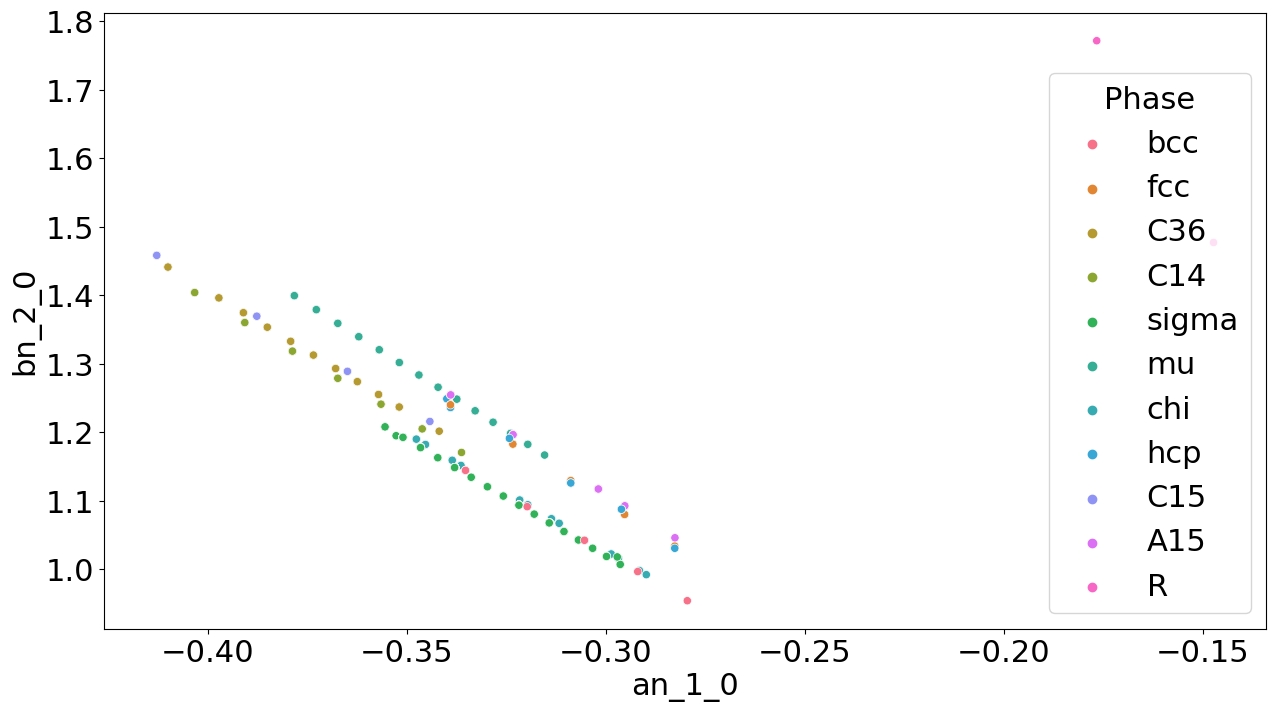

In [41]:
ax = sns.scatterplot(data = resultscnav['canonical'][resultscnav['canonical']['bn_2_0']<4], x = 'an_1_0', y ='bn_2_0', hue=BS.Phase)

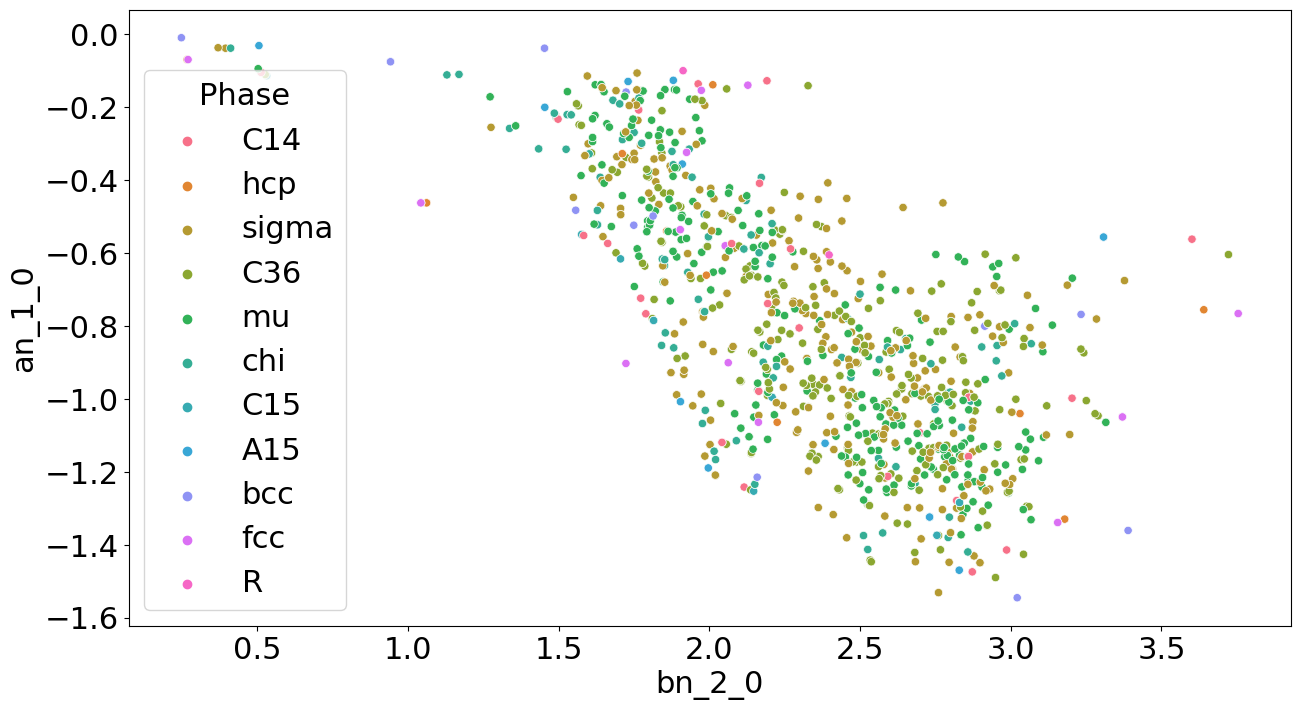

In [42]:
ax = sns.scatterplot(data = resultscnav['projections'], x = 'bn_2_0', y ='an_1_0', hue=BS.Phase)

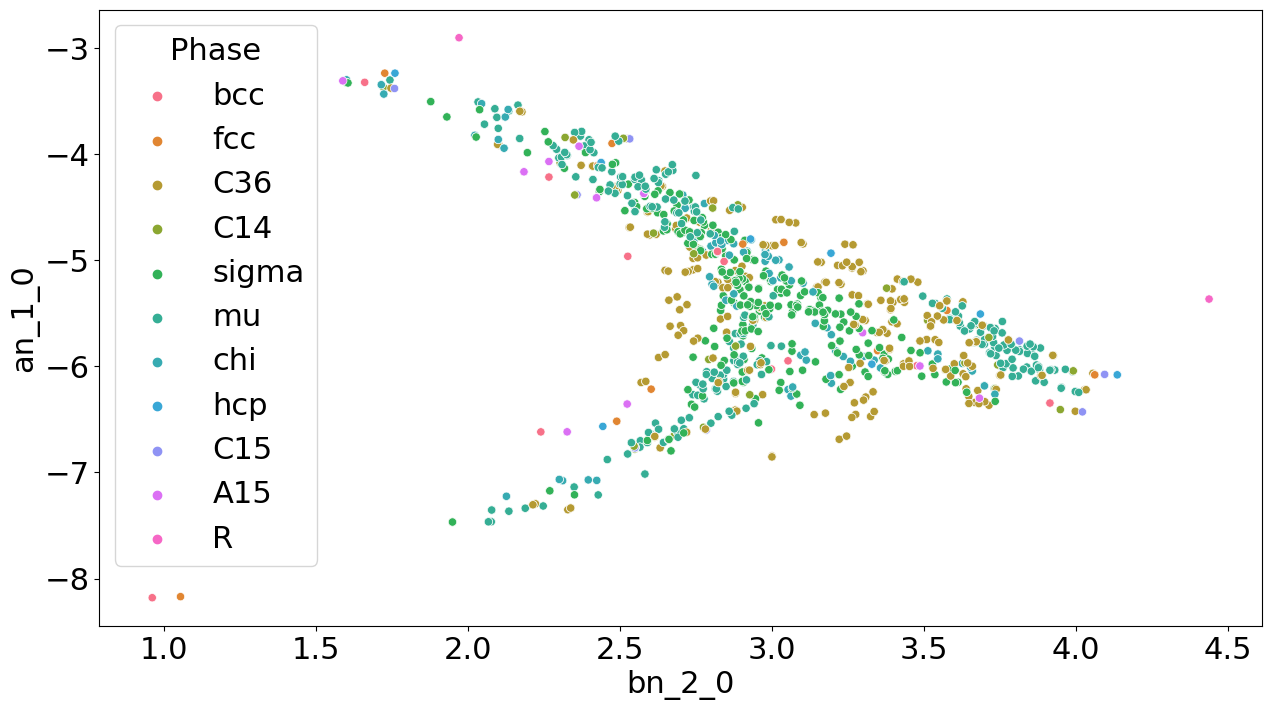

In [67]:
ax = sns.scatterplot(data = resultscnav['projections_os'][resultscnav['projections_os']['bn_2_0']<6], x = 'bn_2_0', y ='an_1_0', hue=BS.Phase)

In [65]:
resultscnav.keys()

dict_keys(['canonical', 'projections', 'projections_os'])